### Imports

In [77]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
from sklearn.preprocessing import StandardScaler
import nbformat

In [6]:
df = pd.read_csv('data/clean/mp_shots_cleaner.csv')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1028007 entries, 0 to 1028006
Data columns (total 88 columns):
 #   Column                                                 Non-Null Count    Dtype  
---  ------                                                 --------------    -----  
 0   xcordadjusted                                          1028007 non-null  int64  
 1   shotangle                                              1028007 non-null  float64
 2   defendingteammaxtimeonicesincefaceoff                  1028007 non-null  float64
 3   playerpositionthatdidevent                             1028007 non-null  str    
 4   shootingteammintimeoniceofforwardssincefaceoff         1028007 non-null  float64
 5   defendingteamaveragetimeoniceofdefencemensincefaceoff  1028007 non-null  float64
 6   shotanglereboundroyalroad                              1028007 non-null  int64  
 7   time                                                   1028007 non-null  int64  
 8   shootingteamdefencemenonice      

In [8]:
int_shots = df.select_dtypes('int64').columns
float_shots = df.select_dtypes('float64').columns

df[int_shots] = df[int_shots].apply(pd.to_numeric, downcast='integer')
df[float_shots] = df[float_shots].apply(pd.to_numeric, downcast='float')

obj_shots = df.select_dtypes(include=['object']).columns

for col in obj_shots:
    num_unique = df[col].nunique()
    num_total = len(df[col])
    
    if num_unique / num_total < 0.5:
        df[col] = df[col].astype('category')

C:\Users\chris\AppData\Local\Temp\ipykernel_36464\513985881.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_shots = df.select_dtypes(include=['object']).columns


In [9]:
# Find home columns (away columns use same naming conventions)
for col in df.columns:
    if 'home' in col:
        print(col)

homepenalty1length
homeemptynet
homepenalty1timeleft
hometeamgoals
ishometeam
homeskatersonice


In [10]:
# Skaters on ice, removing home/away columns
df = df.drop(columns = ['homeskatersonice', 'awayskatersonice'], errors='ignore')
df['shootingteamplayersonice'] = df['shootingteamdefencemenonice'] + df['shootingteamforwardsonice']
df['defendingteamplayersonice'] = df['defendingteamdefencemenonice'] + df['defendingteamforwardsonice']

In [11]:
# Dropping goal count and home/away empty net
df = df.drop(columns= ['hometeamgoals', 'awayteamgoals', 'awayemptynet', 'homeemptynet'], errors='ignore')

In [12]:
# Fix home/away penalty stats
df['powerplaylength'] = np.where((df['ishometeam']==1), df['homepenalty1length'], df['awaypenalty1length'])
df['penaltykilllength'] = np.where((df['ishometeam']==1), df['awaypenalty1length'], df['homepenalty1length'])
df['powerplaytimeleft'] = np.where((df['ishometeam']==1), df['homepenalty1timeleft'], df['awaypenalty1timeleft'])
df['penaltykilltimeleft'] = np.where((df['ishometeam']==1), df['awaypenalty1timeleft'], df['homepenalty1timeleft'])

In [13]:
# Drop home/away penalty stats
df = df.drop(columns = ['homepenalty1length', 'awaypenalty1length', 'homepenalty1timeleft', 'awaypenalty1timeleft'], errors='ignore')

In [14]:
# Recheck
for col in df.columns:
    if 'away' in col:
        print(col)

In [15]:
# Drop non relative and redundant measurements
df = df.drop(columns = ['xcord', 'ycord', 'shotangle', 'shotangleadjusted', 'shotdistance',
                        'lasteventxcord', 'lasteventycord', 'lasteventshotangle', 'location'],
             errors='ignore'
            )

In [16]:
# Fix lasteventteam values
df = df[df['lasteventteam'].isin(['HOME', 'AWAY'])]
df.loc[:, 'lasteventhometeam'] = df['lasteventteam'] == 'HOME'
df = df.drop(columns=['lasteventteam'], errors='ignore')
df['lasteventhometeam'] = df['lasteventhometeam'].astype('int8')

In [17]:
cat_cols = df.select_dtypes(exclude=np.number).columns
cat_cols

Index(['playerpositionthatdidevent', 'shottype', 'lasteventcategory'], dtype='str')

In [18]:
# Fix lasteventcategory values
for col in cat_cols:
    df[col] = df[col].astype("string")
    vc = df[col].value_counts()
    rare = vc[vc < 100].index
    df[col] = df[col].replace(rare, "OTHER")

In [19]:
# Drop shotwasongoal
#   After an initial round of testing, shotwasongoal was by far the most important feature, and I realized that it is dependent on the outcome of the shot and a source of data leakage
df = df.drop(columns='shotwasongoal', errors='ignore')

### Train-test split

In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV

In [21]:
X = df.drop('goal', axis=1)
y= df['goal'].copy()

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=12)

In [23]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((719472, 73), (308346, 73), (719472,), (308346,))

In [24]:
# Scaling
scale_cols = [
    'xcordadjusted', 'time', 'lasteventshotdistance', 'averagerestdifference', 'lasteventxcord_adjusted',
    'lasteventycord_adjusted', 'timedifferencesincechange', 'timesincelastevent', 'timesincefaceoff',
    'shotangleplusrebound', 'distancefromlastevent', 'speedfromlastevent', 'ycordadjusted',
    'shotangleplusreboundspeed', 'powerplaylength', 'penaltykilllength', 'powerplaytimeleft', 'penaltykilltimeleft',
    # TOI Features
    *(c for c in X.columns if 'timeonice' in c)
]
scaler = StandardScaler()
scaler.fit(X_train[scale_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [25]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

In [26]:
# Get Dummies
cat_cols = X_train_scaled.select_dtypes(exclude=np.number).columns
cat_cols

Index(['playerpositionthatdidevent', 'shottype', 'lasteventcategory'], dtype='str')

In [27]:
X_train_scaled_encoded = pd.get_dummies(X_train_scaled, columns=cat_cols, drop_first=True)
X_test_scaled_encoded = pd.get_dummies(X_test_scaled, columns=cat_cols, drop_first=True)
X_test_scaled_encoded = X_test_scaled_encoded.reindex(columns=X_train_scaled_encoded.columns, fill_value=0)
assert list(X_train_scaled_encoded.columns) == list(X_test_scaled_encoded.columns)

In [28]:
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)
assert list(X_train_encoded.columns) == list(X_test_encoded.columns)

In [29]:
del X_train, X_test, X_train_scaled, X_test_scaled
import gc; gc.collect()

91

# Models

In [60]:
# Imports
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    log_loss,
)
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [31]:
print(xgb.__version__)
print(xgb.build_info())

3.1.3
{'BUILTIN_PREFETCH_PRESENT': False, 'CUDA_VERSION': [12, 5], 'DEBUG': False, 'MM_PREFETCH_PRESENT': True, 'THRUST_VERSION': [2, 6, 1], 'USE_CUDA': True, 'USE_DLOPEN_NCCL': False, 'USE_FEDERATED': False, 'USE_NCCL': False, 'USE_NVCOMP': False, 'USE_OPENMP': True, 'USE_RMM': False, 'libxgboost': 'C:\\Users\\chris\\AppData\\Local\\Python\\pythoncore-3.14-64\\Lib\\site-packages\\xgboost\\lib\\xgboost.dll'}


### Parameter grids

In [32]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "l1_ratio": [0,1]
}

XGB_param_grid = {
    "n_estimators":[600, 1000, 1600],
   "learning_rate":[0.02, 0.05, 0.1],
   "max_depth":[3, 6, 9],
   "subsample":[0.5, 0.9],
   "min_child_weight":[1, 5, 10]
}

RF_param_grid = {
    "n_estimators":[50, 100, 200],
    "max_depth":[3, 6, 9],
    "min_samples_leaf":[1,5,10]
}

In [33]:
# Logistic Regression
logreg_search = GridSearchCV(
    LogisticRegression(
        solver="saga",
        max_iter=1000,
        class_weight="balanced",
        random_state=12),
    lr_param_grid,
    n_jobs=-2,
    verbose=3,
    scoring="average_precision")

# XGBoost
num_pos = (y_train == 1).sum()
num_neg = (y_train == 0).sum()
xgboost_search = RandomizedSearchCV(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=(num_neg / num_pos),
        tree_method="hist",
        device="cuda",
        random_state=12),
    XGB_param_grid,
    verbose=3,
    n_jobs=1,
    error_score="raise",
    scoring="average_precision")

# Random Forest
rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        criterion="gini",
        class_weight="balanced_subsample",
        random_state=12
        ),
    RF_param_grid,
    n_jobs=-2,
    verbose=2,
    scoring="average_precision")


In [34]:
results = []

### Logistic Regression

In [35]:
logreg_search.fit(X_train_scaled_encoded, y_train)
best_idx = logreg_search.best_index_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [36]:
best_model = logreg_search.best_estimator_
logreg_test_pred = best_model.predict(X_test_scaled_encoded)
logreg_holdout_ap = average_precision_score(y_test, logreg_test_pred)

results.append({
    "model": "LogisticRegression",
    "cv_mean": logreg_search.best_score_,
    "cv_std": logreg_search.cv_results_["std_test_score"][best_idx],
    "best_params": logreg_search.best_params_,
    "holdout_ap": logreg_holdout_ap
})


In [37]:
print(
    f"LogisticRegression "
    f"CV mean: {logreg_search.best_score_:.4f} | "
    f"CV std: {logreg_search.cv_results_["std_test_score"][best_idx]:.4f} | "
    f"holdout AP: {logreg_holdout_ap:.4f}"
)
print(results)


LogisticRegression CV mean: 0.2193 | CV std: 0.0031 | holdout AP: 0.1074
[{'model': 'LogisticRegression', 'cv_mean': np.float64(0.2192843409944106), 'cv_std': np.float64(0.0031327155394738123), 'best_params': {'C': 1, 'l1_ratio': 1}, 'holdout_ap': 0.10743764247740811}]


In [38]:
logreg_importances = pd.Series(best_model.coef_.ravel(),index=X_train_scaled_encoded.columns).sort_values(key=lambda s: s.abs(), ascending=False)
logreg_importances.head(20)

shotonemptynet                               5.356349
lasteventcategory_OTHER                      2.632667
playerpositionthatdidevent_OTHER            -1.943634
defendingteamplayersonice                   -0.920035
shotrebound                                  0.720097
xcordadjusted                                0.710993
shottype_WRAP                               -0.648256
shotrush                                     0.605724
shottype_SNAP                                0.560467
shottype_SLAP                                0.559104
penaltykilllength                           -0.463503
shotanglereboundroyalroad                    0.447533
lasteventcategory_PENL                       0.446304
defendingteamaveragetimeonicesincefaceoff    0.327796
shottype_DEFL                                0.320520
shootingteamaveragetimeonicesincefaceoff     0.295667
shottype_TIP                                 0.273055
shootingteamplayersonice                     0.264697
lasteventcategory_DELPEN    

In [39]:
del logreg_search
import gc; gc.collect()

32

### XGBoost

In [40]:
xgboost_search.fit(X_train_encoded, y_train)
best_idx = xgboost_search.best_index_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END learning_rate=0.02, max_depth=9, min_child_weight=10, n_estimators=600, subsample=0.5;, score=0.367 total time=   7.9s
[CV 2/5] END learning_rate=0.02, max_depth=9, min_child_weight=10, n_estimators=600, subsample=0.5;, score=0.364 total time=   7.9s
[CV 3/5] END learning_rate=0.02, max_depth=9, min_child_weight=10, n_estimators=600, subsample=0.5;, score=0.366 total time=   7.8s
[CV 4/5] END learning_rate=0.02, max_depth=9, min_child_weight=10, n_estimators=600, subsample=0.5;, score=0.376 total time=   7.6s
[CV 5/5] END learning_rate=0.02, max_depth=9, min_child_weight=10, n_estimators=600, subsample=0.5;, score=0.368 total time=   7.7s
[CV 1/5] END learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=600, subsample=0.9;, score=0.346 total time=   3.6s
[CV 2/5] END learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=600, subsample=0.9;, score=0.342 total time=   3.6s
[CV 3/5] END lear

In [41]:
best_model = xgboost_search.best_estimator_
xgb_test_pred = best_model.predict(X_test_encoded)
xgb_holdout_ap = average_precision_score(y_test, xgb_test_pred)

results.append({
    "model": "XGBClassifier",
    "cv_mean": xgboost_search.best_score_,
    "cv_std": xgboost_search.cv_results_["std_test_score"][best_idx],
    "best_params": xgboost_search.best_params_,
    "holdout_ap": xgb_holdout_ap
})


In [42]:
print(
    f"XGBoostClassifier "
    f"CV mean: {xgboost_search.best_score_:.4f} | "
    f"CV std: {xgboost_search.cv_results_["std_test_score"][best_idx]:.4f} | "
    f"best_params: {xgboost_search.best_params_} | "
    f"holdout AP: {xgb_holdout_ap:.4f}"
)


XGBoostClassifier CV mean: 0.3707 | CV std: 0.0043 | best_params: {'subsample': 0.9, 'n_estimators': 1600, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.02} | holdout AP: 0.1405


In [43]:
xgb_importances = pd.Series(best_model.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)
xgb_importances.head(20)


shotonemptynet                          0.136509
ishometeam                              0.054158
defendingteamplayersonice               0.053426
powerplaylength                         0.046929
penaltykilllength                       0.044443
shootingteamplayersonice                0.039992
xcordadjusted                           0.038163
penaltykilltimeleft                     0.038078
shootingteamforwardsonice               0.034629
shotanglereboundroyalroad               0.030127
ycordadjusted                           0.026279
shotrebound                             0.023094
shottype_SNAP                           0.020368
shottype_WRAP                           0.018452
shootingteammintimeonicesincefaceoff    0.017698
shootingteamdefencemenonice             0.016105
lasteventcategory_HIT                   0.015544
shottype_WRIST                          0.014934
shottype_TIP                            0.014834
shottype_SLAP                           0.013756
dtype: float32

In [44]:
results

[{'model': 'LogisticRegression',
  'cv_mean': np.float64(0.2192843409944106),
  'cv_std': np.float64(0.0031327155394738123),
  'best_params': {'C': 1, 'l1_ratio': 1},
  'holdout_ap': 0.10743764247740811},
 {'model': 'XGBClassifier',
  'cv_mean': np.float64(0.37066026344517555),
  'cv_std': np.float64(0.004292002871817785),
  'best_params': {'subsample': 0.9,
   'n_estimators': 1600,
   'min_child_weight': 5,
   'max_depth': 6,
   'learning_rate': 0.02},
  'holdout_ap': 0.14053813869827803}]

In [45]:
del xgboost_search
import gc; gc.collect()

58320

### Random Forest

In [46]:
# random forest
rf_search.fit(X_train_encoded, y_train)
best_idx = rf_search.best_index_

best_model = rf_search.best_estimator_
rf_test_pred = best_model.predict(X_test_encoded)
rf_holdout_ap = average_precision_score(y_test, rf_test_pred)

results.append({
    "model": "RandomForestClassifier",
    "cv_mean": rf_search.best_score_,
    "cv_std": rf_search.cv_results_["std_test_score"][best_idx],
    "best_params": rf_search.best_params_,
    "holdout_ap": rf_holdout_ap
})


Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [47]:
print(
    f"RandomForestClassifier "
    f"CV mean: {rf_search.best_score_:.4f} | "
    f"CV std: {rf_search.cv_results_["std_test_score"][best_idx]:.4f} | "
    f"best_params: {rf_search.best_params_} | "
    f"holdout AP: {rf_holdout_ap:.4f}"
)


RandomForestClassifier CV mean: 0.2569 | CV std: 0.0027 | best_params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 9} | holdout AP: 0.1175


In [48]:
results

[{'model': 'LogisticRegression',
  'cv_mean': np.float64(0.2192843409944106),
  'cv_std': np.float64(0.0031327155394738123),
  'best_params': {'C': 1, 'l1_ratio': 1},
  'holdout_ap': 0.10743764247740811},
 {'model': 'XGBClassifier',
  'cv_mean': np.float64(0.37066026344517555),
  'cv_std': np.float64(0.004292002871817785),
  'best_params': {'subsample': 0.9,
   'n_estimators': 1600,
   'min_child_weight': 5,
   'max_depth': 6,
   'learning_rate': 0.02},
  'holdout_ap': 0.14053813869827803},
 {'model': 'RandomForestClassifier',
  'cv_mean': np.float64(0.25690071661982095),
  'cv_std': np.float64(0.0026564269783725426),
  'best_params': {'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 9},
  'holdout_ap': 0.11745223408504615}]

In [49]:
del rf_search
import gc; gc.collect()

86

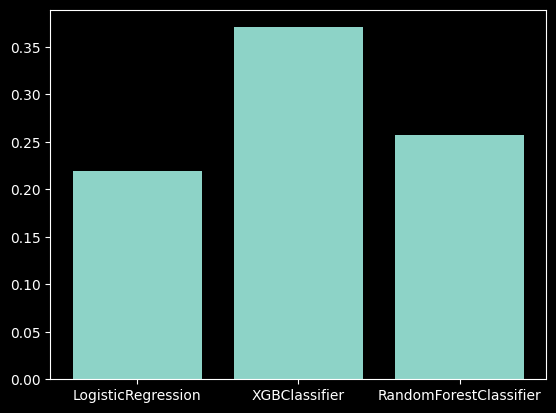

In [84]:
results_df = pd.DataFrame(results)
plt.bar(results_df['model'], results_df['cv_mean'])
plt.show()

Based on these results, the XGBClassifier performed best with an average area under the precision recall curve (PR-AUC) of 0.37. However, the number of false positives is far too high for my liking. I think I need to figure out how to tune this so that the number of predicted goals is roughly the same as the number of actual goals.

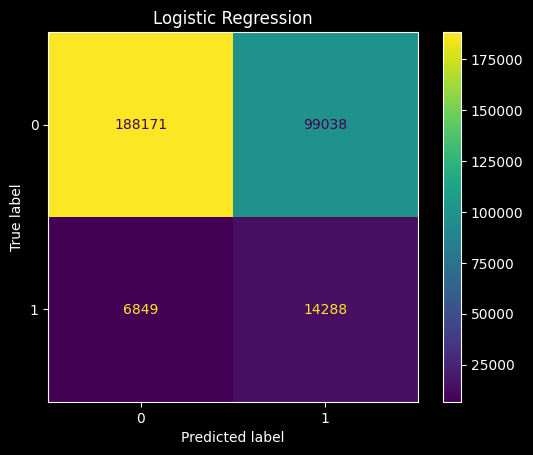

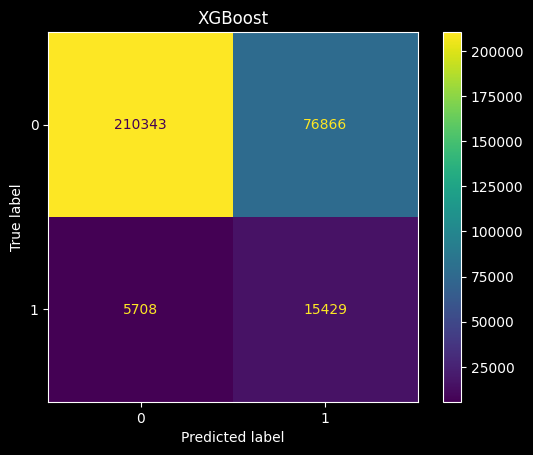

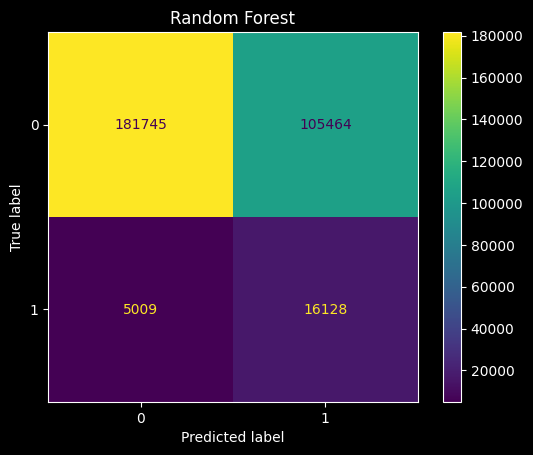

In [94]:
predictions = {
    'Logistic Regression': logreg_test_pred,
    'XGBoost': xgb_test_pred,
    'Random Forest': rf_test_pred
}
for model, prediction in predictions.items():
    cfm = confusion_matrix(y_test, prediction)
    disp = ConfusionMatrixDisplay(cfm)
    disp.plot()
    plt.title(model)

In [68]:
cfm = confusion_matrix(y_test, xgb_test_pred, labels=[0, 1])
print(y_test.sum()/len(y_test))
print(cfm)


0.0685496163400855
[[210343  76866]
 [  5708  15429]]
